Importing Necessary Libraries

In [ ]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from wordcloud import WordCloud,STOPWORDS
import plotly.express as px


Read the data.

In [ ]:
data = pd.read_csv('survey data demographics.csv')

In [ ]:
data.head()

,Respondent,MainBranch,Hobbyist,OpenSourcer,OpenSource,Employment,Country,Student,EdLevel,UndergradMajor,...,WelcomeChange,SONewContent,Age,Gender,Trans,Sexuality,Ethnicity,Dependents,SurveyLength,SurveyEase
0,4,I am a developer by profession,No,Never,The quality of OSS and closed source software ...,Employed full-time,United States,No,"Bachelor’s degree (BA, BS, B.Eng., etc.)","Computer science, computer engineering, or sof...",...,Just as welcome now as I felt last year,Tech articles written by other developers;Indu...,22.0,Man,No,Straight / Heterosexual,White or of European descent,No,Appropriate in length,Easy
1,9,I am a developer by profession,Yes,Once a month or more often,The quality of OSS and closed source software ...,Employed full-time,New Zealand,No,Some college/university study without earning ...,"Computer science, computer engineering, or sof...",...,Just as welcome now as I felt last year,NaN,23.0,Man,No,Bisexual,White or of European descent,No,Appropriate in length,Neither easy nor difficult
2,13,I am a developer by profession,Yes,Less than once a month but more than once per ...,"OSS is, on average, of HIGHER quality than pro...",Employed full-time,United States,No,"Master’s degree (MA, MS, M.Eng., MBA, etc.)","Computer science, computer engineering, or sof...",...,Somewhat more welcome now than last year,Tech articles written by other developers;Cour...,28.0,Man,No,Straight / Heterosexual,White or of European descent,Yes,Appropriate in length,Easy
3,16,I am a developer by profession,Yes,Never,The quality of OSS and closed source software ...,Employed full-time,United Kingdom,No,"Master’s degree (MA, MS, M.Eng., MBA, etc.)",NaN,...,Just as welcome now as I felt last year,Tech articles written by other developers;Indu...,26.0,Man,No,Straight / Heterosexual,White or of European descent,No,Appropriate in length,Neither easy nor difficult
4,17,I am a developer by profession,Yes,Less than once a month but more than once per ...,The quality of OSS and closed source software ...,Employed full-time,Australia,No,"Bachelor’s degree (BA, BS, B.Eng., etc.)","Computer science, computer engineering, or sof...",...,Just as welcome now as I felt last year,Tech articles written by other developers;Indu...,29.0,Man,No,Straight / Heterosexual,Hispanic or Latino/Latina;Multiracial,No,Appropriate in length,Easy


In [ ]:
#How many are developers
data["MainBranch"].value_counts()

I am a developer by profession                                                   10618
I am not primarily a developer, but I write code sometimes as part of my work      780
Name: MainBranch, dtype: int64

Datatypes of the columns.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11398 entries, 0 to 11397
Data columns (total 70 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Respondent      11398 non-null  int64  
 1   MainBranch      11398 non-null  object 
 2   Hobbyist        11398 non-null  object 
 3   OpenSourcer     11398 non-null  object 
 4   OpenSource      11317 non-null  object 
 5   Employment      11398 non-null  object 
 6   Country         11398 non-null  object 
 7   Student         11347 non-null  object 
 8   EdLevel         11286 non-null  object 
 9   UndergradMajor  10661 non-null  object 
 10  EduOther        11234 non-null  object 
 11  OrgSize         11302 non-null  object 
 12  DevType         11333 non-null  object 
 13  YearsCode       11389 non-null  object 
 14  Age1stCode      11385 non-null  object 
 15  YearsCodePro    11382 non-null  object 
 16  CareerSat       11398 non-null  object 
 17  JobSat          11397 non-null 

In [ ]:
data.isna().sum()

Learn about the respondent demographics.

What are age range are the developers.

In [ ]:
age_counts = data["Age"].value_counts().sort_values(ascending=True) #age frequency in ascending order

In [ ]:
#bar graph for age
fig = px.bar(age_counts, title="Age of respondents")
fig.update_layout(
    xaxis_title = "Age",
    yaxis_title = "Frequency",
    title_x = 0.5,
    showlegend = False
)
fig.show()

How many years have they been coding?

In [ ]:
age_coding = data["YearsCode"].value_counts().sort_values(ascending=True)# years coded frequency in ascending order

#bar graph for age
fig = px.bar(age_coding, title="Years Coded")
fig.update_layout(
    xaxis_title = "Years",
    yaxis_title = "Frequency",
    title_x = 0.5,
    showlegend = False
)
fig.show()

What countries are the respondents from?

In [ ]:
data['Country'].nunique() # Different countrys

135

In [ ]:
countrys = data['Country'].value_counts()

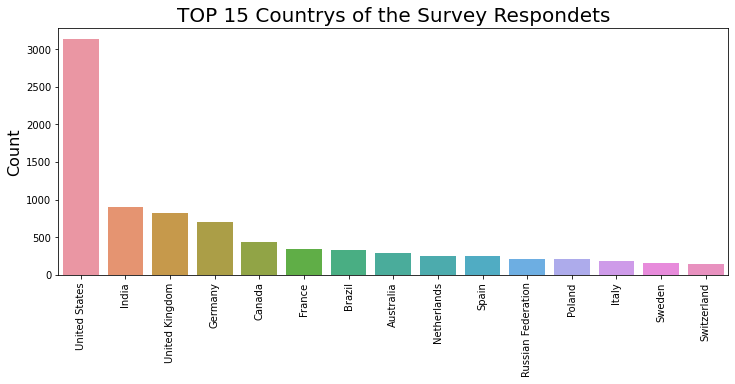

In [ ]:
plt.figure(figsize=(12,10))

plt.subplot(2,1,1)
g = sns.countplot(x='Country',
                  data=data[data.Country.isin(countrys[:15].index.values)],
                  order=countrys[:15].index.values)
g.set_title("TOP 15 Countrys of the Survey Respondets", fontsize=20)
g.set_xlabel("", fontsize=16)
g.set_ylabel("Count", fontsize=16)
g.set_xticklabels(g.get_xticklabels(),rotation=90)

plt.show()

Do they take up coding as a hobby?

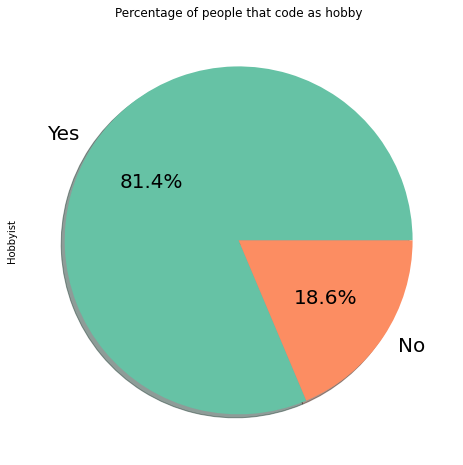

In [ ]:
plt.figure(figsize=(8,8))
data["Hobbyist"].value_counts().plot.pie(autopct = "%1.1f%%",colors = sns.color_palette("Set2"),fontsize=20, shadow =True)
plt.title("Percentage of people that code as hobby")
plt.show()

Social media used wordcloud.

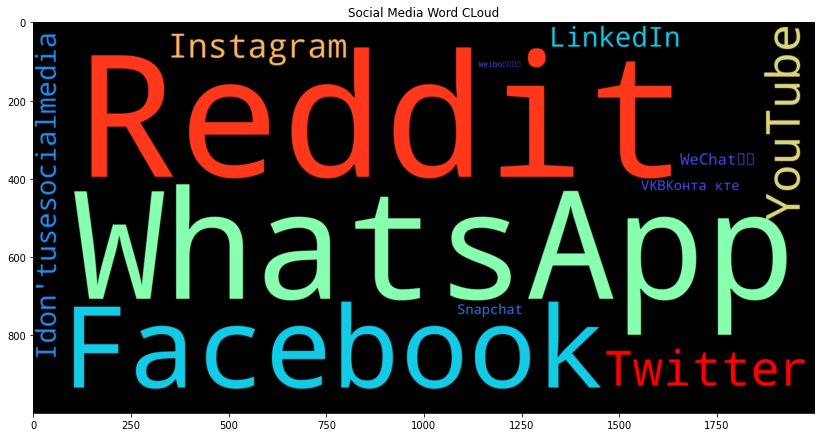

In [ ]:
words = data[data["SocialMedia"].notnull()]["SocialMedia"].str.replace(" ","")
wc = WordCloud(background_color="black",colormap="rainbow",scale=5).generate(" ".join(words))
plt.figure(figsize=(14,10))
plt.imshow(wc,interpolation="bilinear")
plt.axis("on")
plt.title("Social Media Word CLoud")
plt.show()

Family or children.

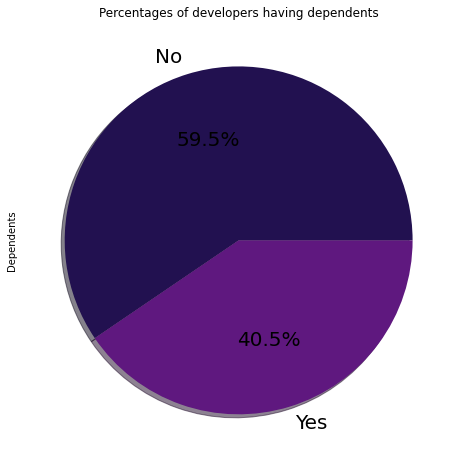

In [ ]:
plt.figure(figsize=(8,8))
data["Dependents"].value_counts().plot.pie(autopct = "%1.1f%%",colors = sns.color_palette("magma"),fontsize=20, shadow =True)
plt.title("Percentages of developers having dependents")
plt.show()

Job related Questions.

How many of respondendts are developers by profession?

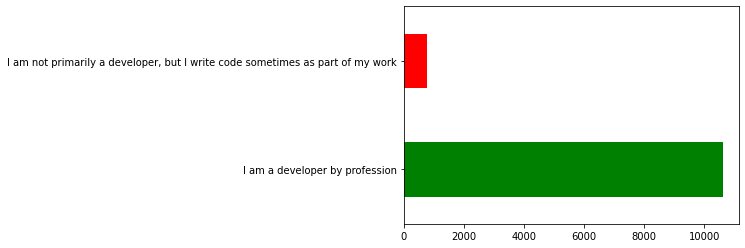

In [ ]:
data["MainBranch"].value_counts().plot(kind="barh", color=["Green", "Red"]);


How many of them are employed?

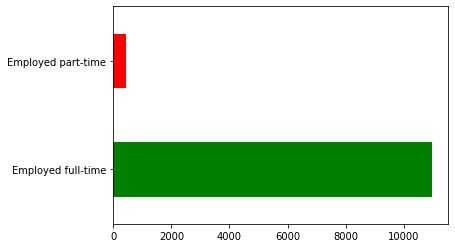

In [ ]:
data["Employment"].value_counts().plot(kind="barh", color=["Green", "Red"]);

In [ ]:
data["Employment"].value_counts()

Employed full-time    10968
Employed part-time      430
Name: Employment, dtype: int64

Are they satisfied with their jobs?

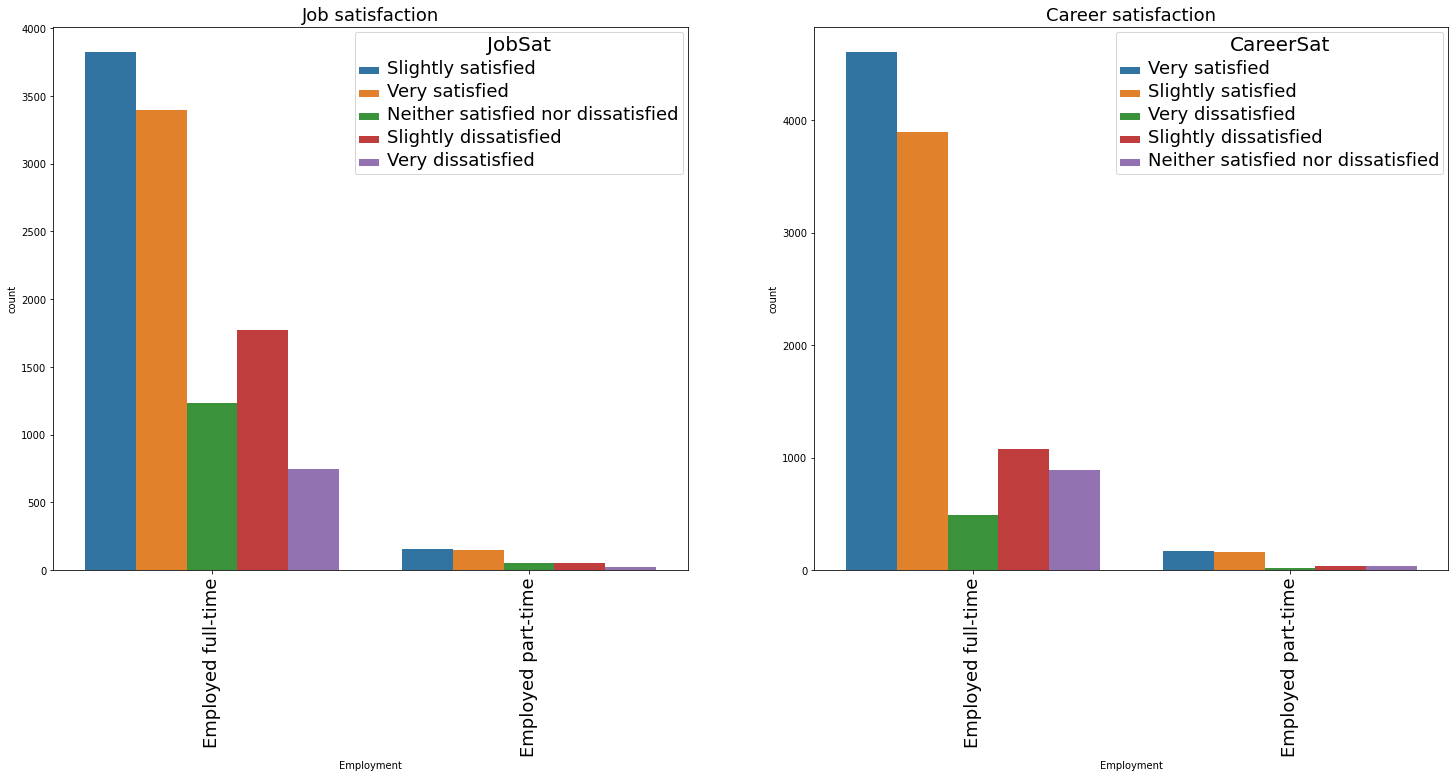

In [ ]:
f,ax=plt.subplots(1,2,figsize=(25,10)) # Double plots

sns.countplot(x='Employment', hue="JobSat", data=data, ax=ax[0])
sns.countplot(x='Employment', hue='CareerSat', data=data, ax=ax[1])
ax[0].set_title('Job satisfaction', fontsize=18)
ax[1].set_title('Career satisfaction', fontsize=18)
ax[0].tick_params(axis='x', labelsize=18,rotation = 90)
ax[1].tick_params(axis='x', labelsize=18, rotation=90)
plt.setp(ax[0].get_legend().get_texts(), fontsize='18')
plt.setp(ax[0].get_legend().get_title(), fontsize='20')
plt.setp(ax[1].get_legend().get_texts(), fontsize='18')
plt.setp(ax[1].get_legend().get_title(), fontsize='20')
plt.show()

What job factors do they think are most important?

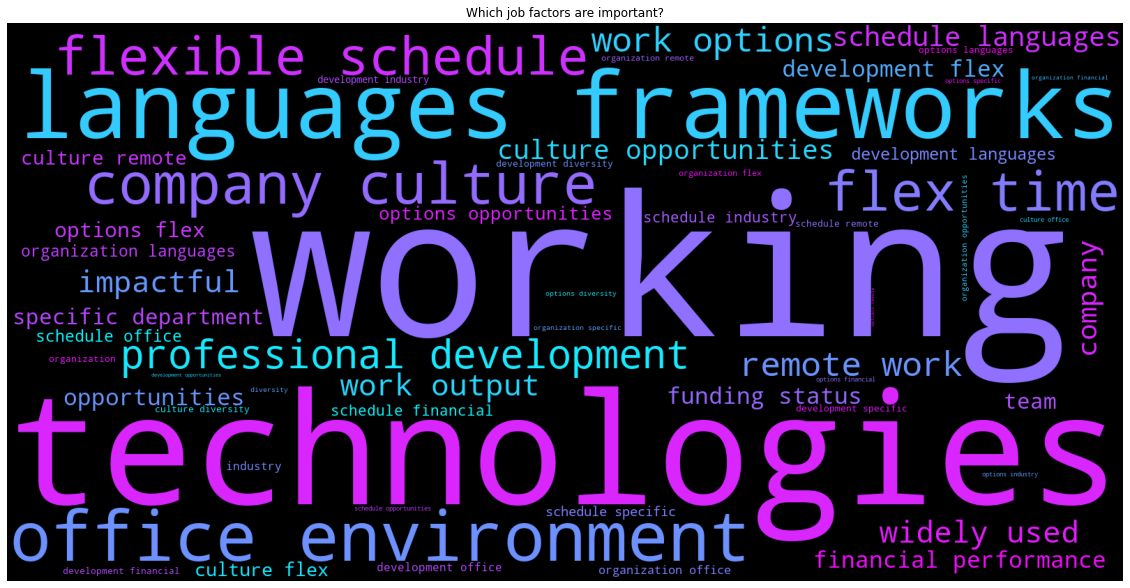

In [ ]:
text = " ".join((data['JobFactors']).astype(str)).lower()
wc = WordCloud(max_words=1200, width = 1600 , height = 800 ,stopwords=STOPWORDS, colormap='cool', background_color='Black').generate(text)
plt.figure(figsize=(20,20))
plt.imshow(wc)
plt.axis('off')
plt.title('Which job factors are important?');

How often do they work remotely?

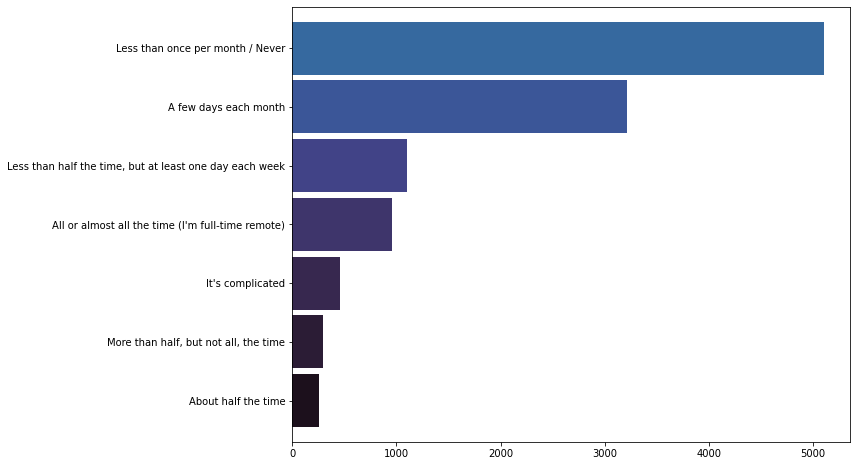

In [ ]:
plt.figure(figsize=(10,8))

data.WorkRemote.value_counts().sort_values(ascending=True).plot.barh(width=0.9,color=sns.color_palette('mako',15))
plt.show()

How long is their work week?

/usr/local/lib/python3.8/dist-packages/seaborn/_decorators.py:36: FutureWarning:

Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.

/usr/local/lib/python3.8/dist-packages/seaborn/categorical.py:1604: MatplotlibDeprecationWarning:

Using a string of single character colors as a color sequence is deprecated. Use an explicit list instead.



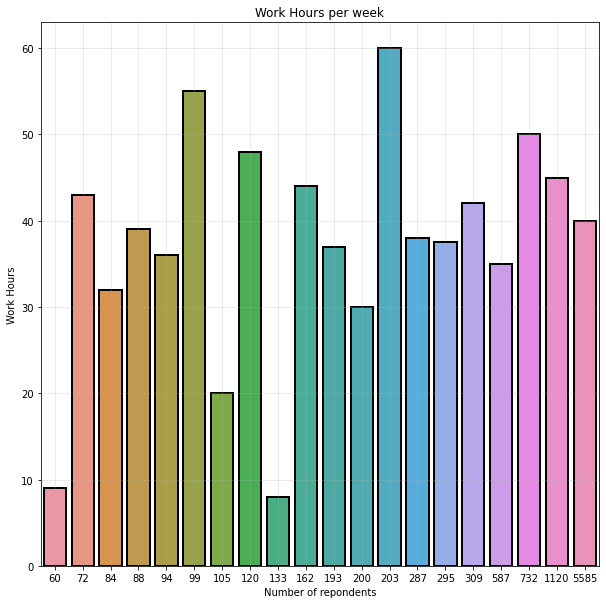

In [ ]:
plt.figure(figsize=(10,10))
work_hours = data["WorkWeekHrs"].value_counts().reset_index()

ax = sns.barplot("WorkWeekHrs","index",data=work_hours[:20],linewidth=2,edgecolor="k"*20)
plt.xlabel("Number of repondents")
plt.ylabel("Work Hours")
plt.title("Work Hours per week")
plt.grid(True,alpha=.3)


Which countries have the highest Salaries?

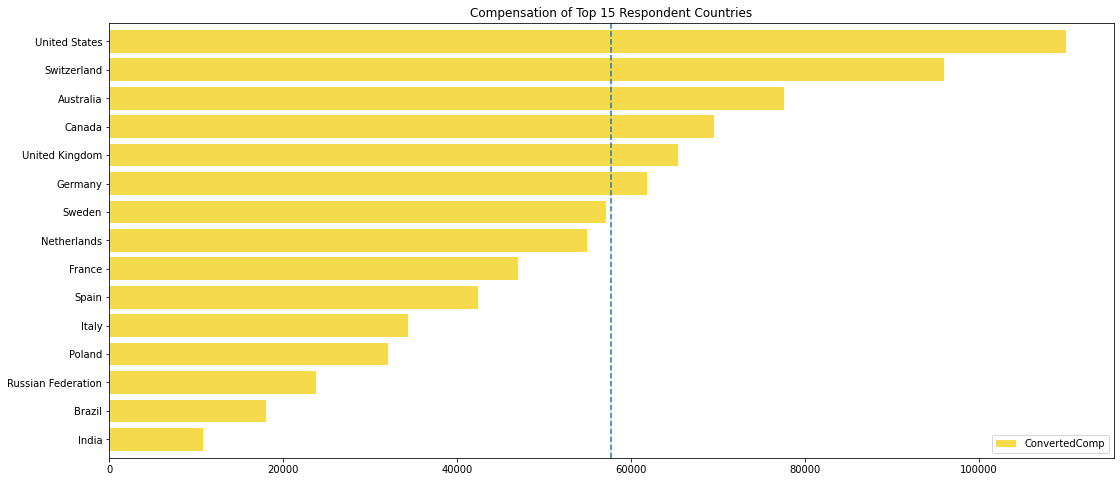

In [ ]:
resp_coun=data['Country'].value_counts()[:15].to_frame()

f,ax=plt.subplots(1,1,figsize=(18,8))
max_coun=data.groupby('Country')['ConvertedComp'].median().to_frame()
max_coun=max_coun[max_coun.index.isin(resp_coun.index)]
max_coun.sort_values(by='ConvertedComp',ascending=True).plot.barh(width=0.8,ax=ax,color=sns.color_palette("inferno_r",10))

ax.axvline(data['ConvertedComp'].median(),linestyle='dashed')
ax.set_title('Compensation of Top 15 Respondent Countries')
ax.set_xlabel('')
ax.set_ylabel('')
plt.subplots_adjust(wspace=0.8)
plt.show()

Stack Overflow Questions


How much time spent on Stack Overflow?



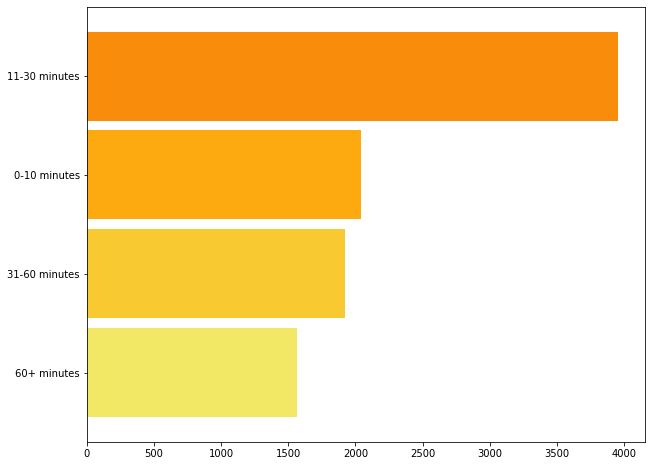

In [ ]:
plt.figure(figsize=(10,8))

data.SOHowMuchTime.value_counts().sort_values(ascending=True).plot.barh(width=0.9,color=sns.color_palette('inferno_r',15))
plt.show()

How frequently Stack Overflow is visited?


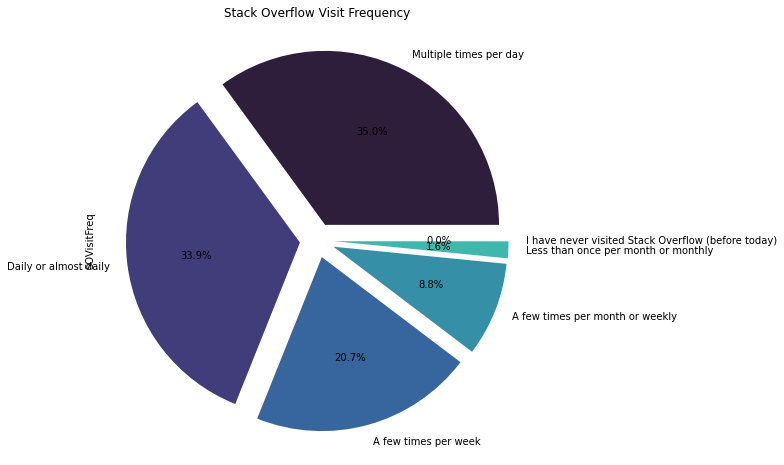

In [ ]:
plt.figure(figsize=(8,8))
data["SOVisitFreq"].value_counts().plot.pie(autopct='%1.1f%%', colors = sns.color_palette("mako"),fontsize=10, explode=[0.1,0.1,0.1,0.1,0.1,0.1])
plt.title('Stack Overflow Visit Frequency');

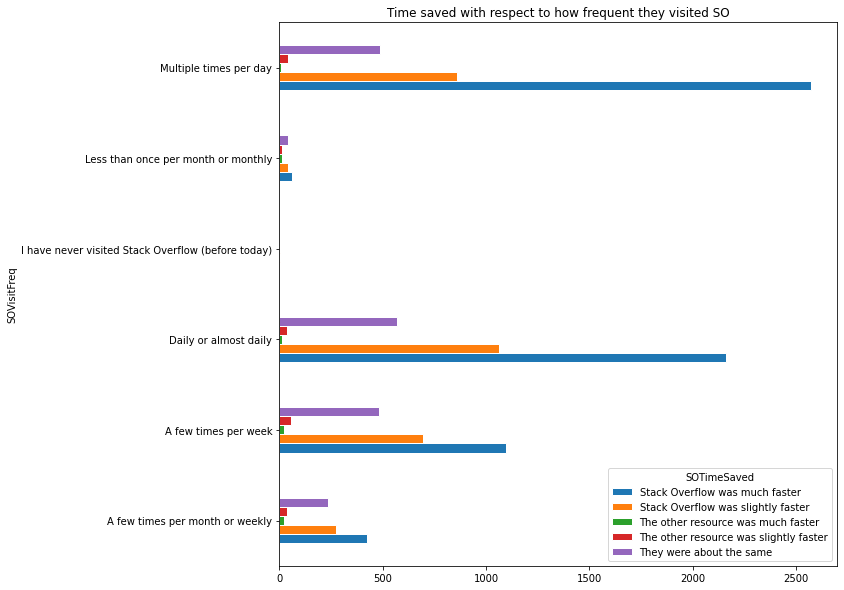

In [ ]:
fig = pd.crosstab(data["SOVisitFreq"],data["SOTimeSaved"]).plot(kind="barh",
                                                             figsize = (10,10),
                                                             linewidth = 1,
                                                             edgecolor = "w"*2)
fig.set_title("Time saved with respect to how frequent they visited SO")
plt.show()

Questions related languages used.

In [ ]:
df_lang = pd.read_csv('survey data technologies normalised.csv')

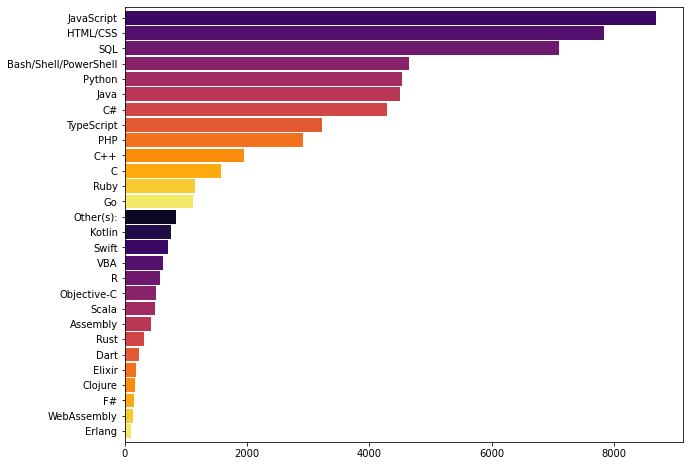

In [ ]:
plt.figure(figsize=(10,8))

df_lang.LanguageWorkedWith.value_counts().sort_values(ascending=True).plot.barh(width=0.9,color=sns.color_palette('inferno_r',15))
plt.savefig('language_used.png')
plt.show()

In [ ]:
df_lang["LanguageDesireNextYear"].value_counts()

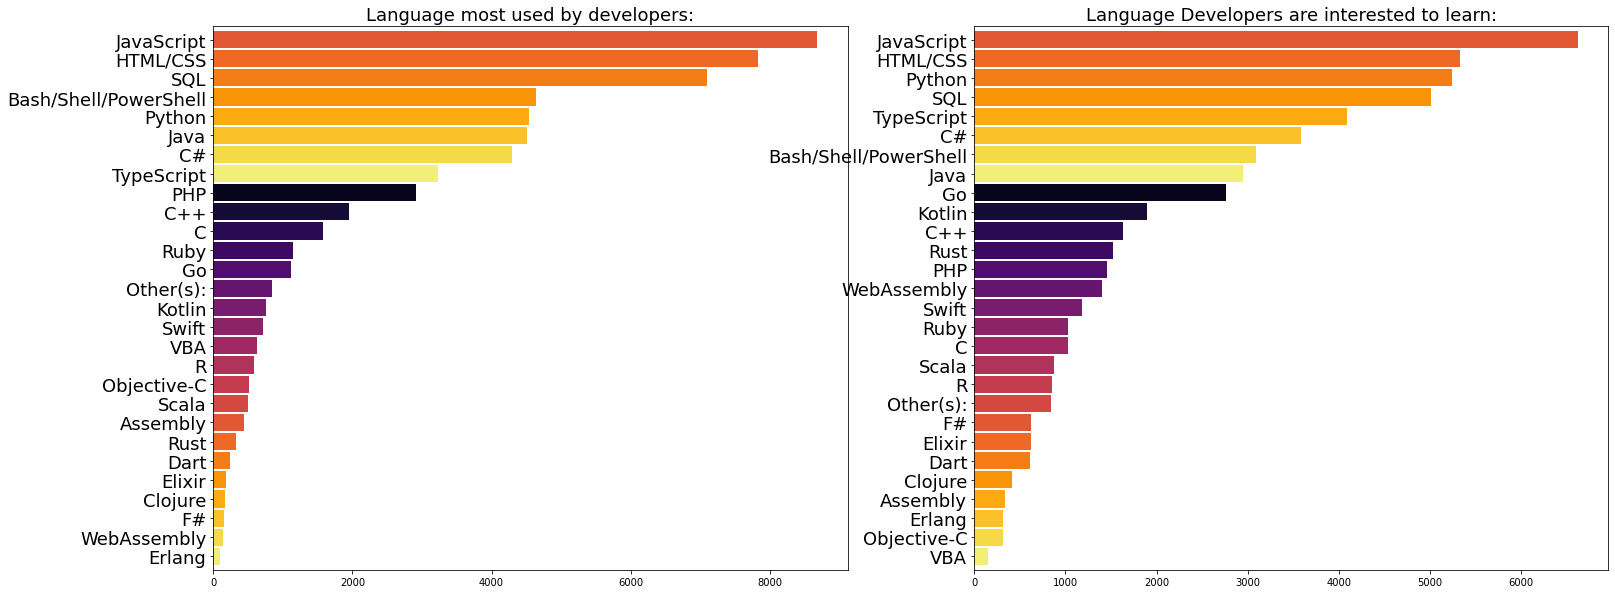

In [ ]:
f,ax=plt.subplots(1,2,figsize=(25,10))

df_lang.LanguageWorkedWith.value_counts().sort_values(ascending=True).plot.barh(width=0.9,color=sns.color_palette('inferno_r',20), ax = ax[0])
df_lang.LanguageDesireNextYear.value_counts().sort_values(ascending=True).plot.barh(width=0.9,color=sns.color_palette('inferno_r',20), ax = ax[1])
ax[0].tick_params(axis='y', labelsize=18)
ax[1].tick_params(axis='y', labelsize=18)
ax[0].set_title('Language most used by developers:', fontsize=18)
ax[1].set_title('Language Developers are interested to learn:', fontsize=18)
plt.show()

Database used or want to use.

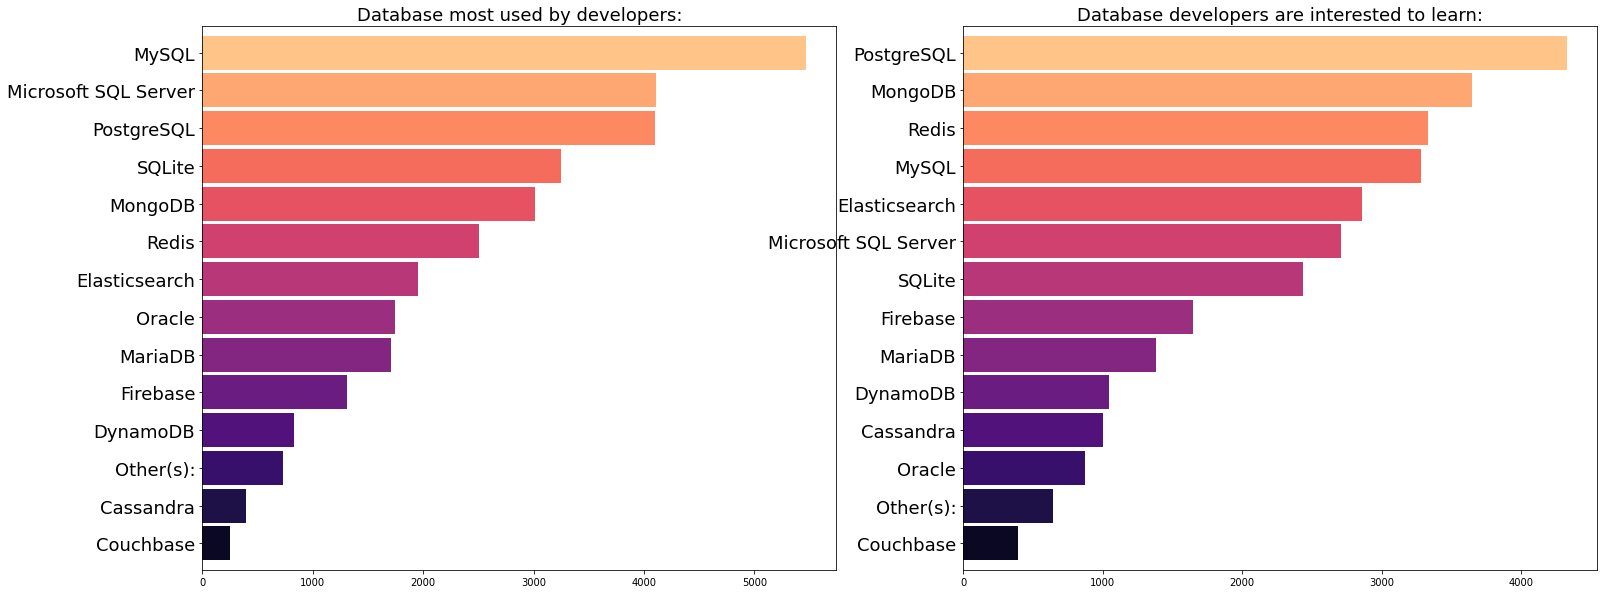

In [ ]:
f,ax=plt.subplots(1,2,figsize=(25,10))

df_lang.DatabaseWorkedWith.value_counts().sort_values(ascending=True).plot.barh(width=0.9,color=sns.color_palette('magma',15), ax = ax[0])
df_lang.DatabaseDesireNextYear.value_counts().sort_values(ascending=True).plot.barh(width=0.9,color=sns.color_palette('magma',15), ax = ax[1])
ax[0].tick_params(axis='y', labelsize=18)
ax[1].tick_params(axis='y', labelsize=18)
ax[0].set_title('Database most used by developers:', fontsize=18)
ax[1].set_title('Database developers are interested to learn:', fontsize=18)
plt.show()

Platforms used and want to use.

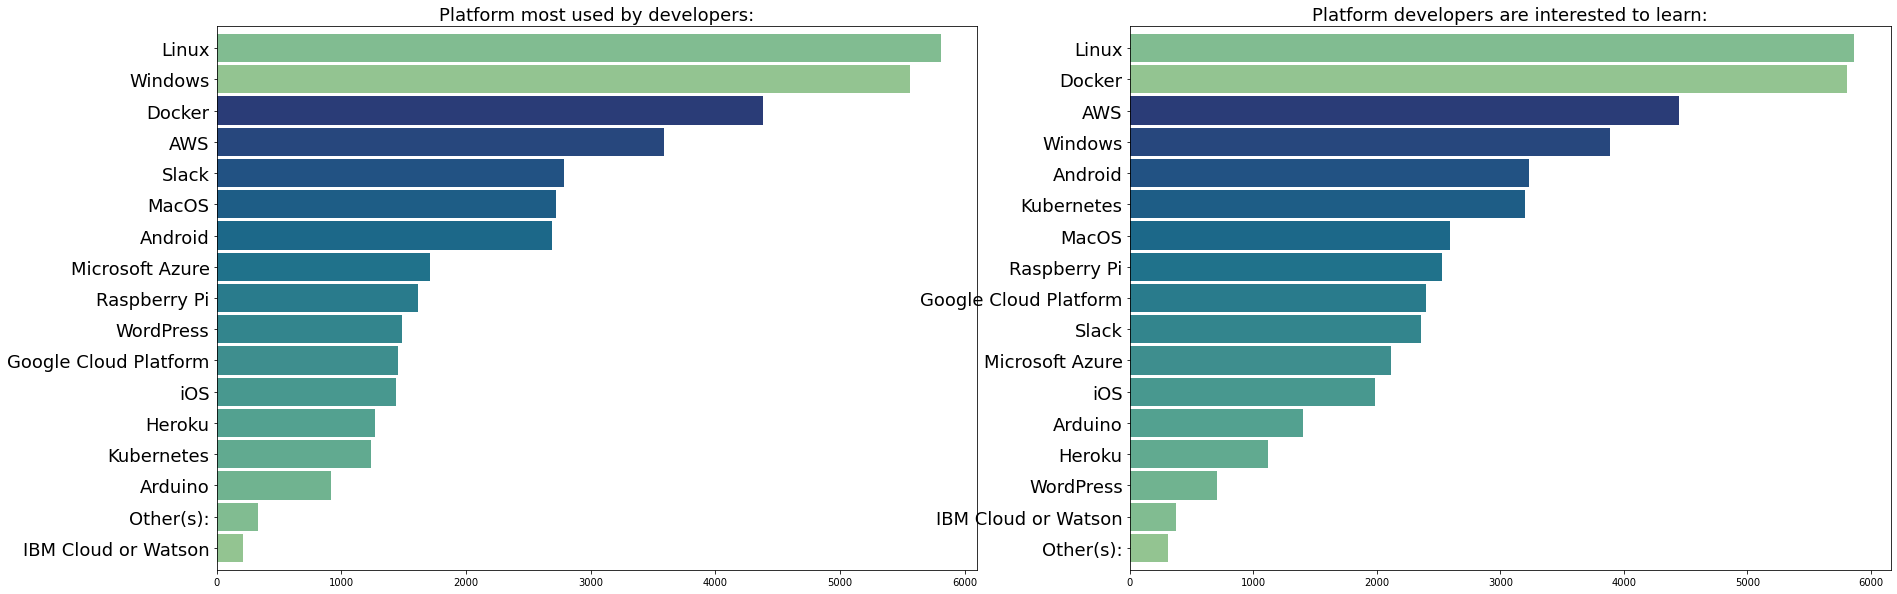

In [ ]:
f,ax=plt.subplots(1,2,figsize=(30,10))

df_lang.PlatformWorkedWith.value_counts().sort_values(ascending=True).plot.barh(width=0.9,color=sns.color_palette('crest',15), ax = ax[0])
df_lang.PlatformDesireNextYear.value_counts().sort_values(ascending=True).plot.barh(width=0.9,color=sns.color_palette('crest',15), ax = ax[1])
ax[0].tick_params(axis='y', labelsize=18)
ax[1].tick_params(axis='y', labelsize=18)
ax[0].set_title('Platform most used by developers:', fontsize=18)
ax[1].set_title('Platform developers are interested to learn:', fontsize=18)
plt.show()

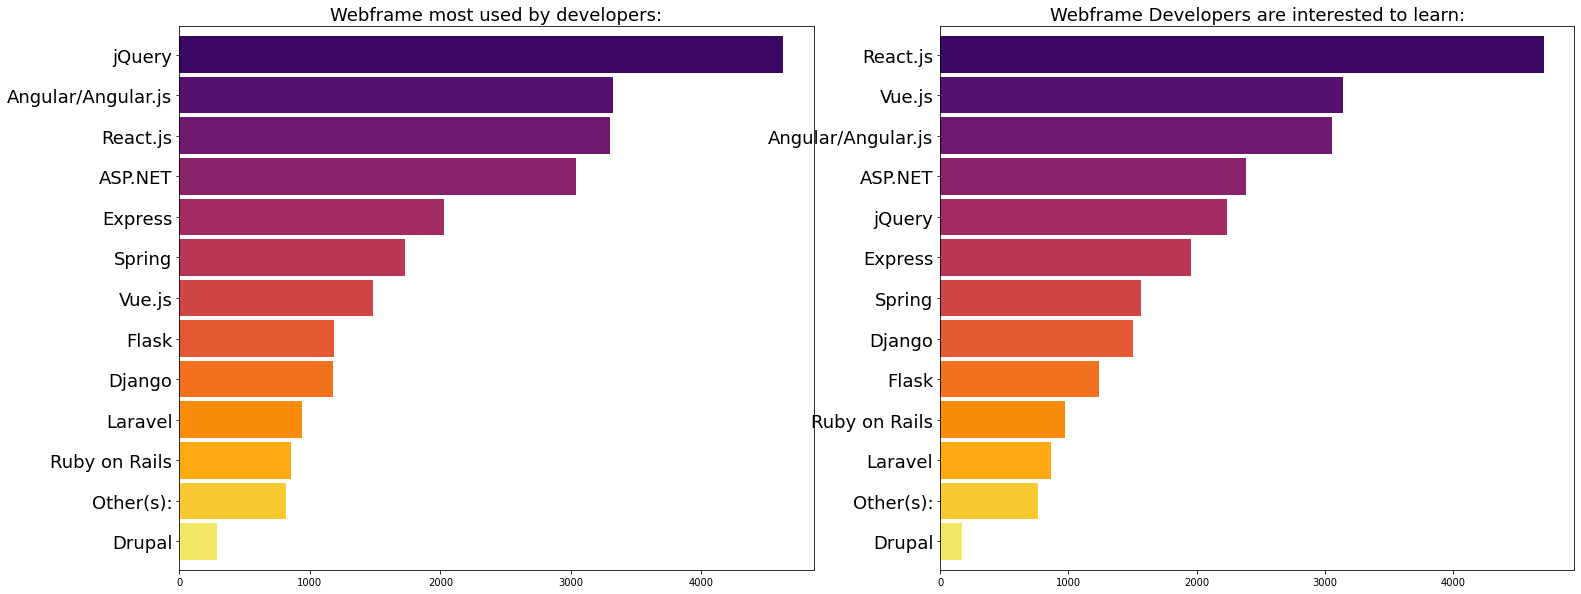

In [ ]:
f,ax=plt.subplots(1,2,figsize=(25,10))

df_lang.WebFrameWorkedWith.value_counts().sort_values(ascending=True).plot.barh(width=0.9,color=sns.color_palette('inferno_r',15), ax = ax[0])
df_lang.WebFrameDesireNextYear.value_counts().sort_values(ascending=True).plot.barh(width=0.9,color=sns.color_palette('inferno_r',15), ax = ax[1])
ax[0].tick_params(axis='y', labelsize=18)
ax[1].tick_params(axis='y', labelsize=18)
ax[0].set_title('Webframe most used by developers:', fontsize=18)
ax[1].set_title('Webframe Developers are interested to learn:', fontsize=18)
plt.show()

Empty values in normalised dataset.

In [ ]:

df_missing = df_lang.isna()

In [ ]:
df_num_missing = df_missing.sum()

In [ ]:
df_num_missing

Respondent                    1
LanguageWorkedWith        14798
LanguageDesireNextYear    18826
DatabaseWorkedWith        43215
DatabaseDesireNextYear    45015
PlatformWorkedWith        35382
PlatformDesireNextYear    30276
WebFrameWorkedWith        49787
WebFrameDesireNextYear    50023
DevEnviron                41284
OpSys                     74590
Containers                74590
BlockchainOrg             74590
BlockchainIs              74590
dtype: int64

In [ ]:
df_num_missing/len(df_lang)

Respondent                0.000013
LanguageWorkedWith        0.198391
LanguageDesireNextYear    0.252393
DatabaseWorkedWith        0.579367
DatabaseDesireNextYear    0.603499
PlatformWorkedWith        0.474353
PlatformDesireNextYear    0.405899
WebFrameWorkedWith        0.667476
WebFrameDesireNextYear    0.670639
DevEnviron                0.553479
OpSys                     1.000000
Containers                1.000000
BlockchainOrg             1.000000
BlockchainIs              1.000000
dtype: float64

The End.